# Africa AI Olympiad — Training Breast Cancer Lesion Detection on High Performance Compute
===========================================================

## Make a copy of this notebook before you start (Copy and Edit in Kaggle Notebooks)

**Challenge Goal:** Build the most accurate object detection model you can to localise breast cancer lesions in mammography images — without ever leaving your notebook, then train it on high performance compute that's a few clicks away.

---

### The Problem

Breast cancer is the most commonly diagnosed cancer in women worldwide. Early detection through mammography screening dramatically improves survival rates — but radiologists reviewing thousands of images per week are prone to fatigue-related misses. Automated lesion detection can act as a tireless second pair of eyes.

Your task is to build a model that draws bounding boxes around lesions in mammogram images. This is an **object detection** problem: the model must answer both *"is there a lesion?"* and *"where exactly is it?"*.

---

### Your Toolkit

| Stage | Tool | Why |
|-------|------|-----|
| Data | VinDr-Mammo PNG (Kaggle) | Pre-converted PNGs, single CSV, CC BY-NC-SA 4.0 |
| Baseline detector | YOLOv8 (Ultralytics) | Fast, notebook-friendly, state-of-the-art |
| Evaluation | mAP@0.5, F1, IoU | Standard object detection metrics |
| Scale-up compute | AfriLink SDK → HPC A100s | Full training run on the cluster |

---

### Recommended Workflow

> **The strategy that wins hackathons:**
>
> 1. **Explore + prototype on Kaggle GPUs** (free T4/P100) — fast iteration, quick feedback.
> 2. **When you have a solid approach**, submit the full training job to the AfriLink HPC cluster’s A100 nodes for a complete, high-quality training run.
>
> Kaggle GPUs are great for debugging dataloaders, checking augmentation pipelines, and validating that your model architecture works. A100s are 5–10× faster for a full 100-epoch run on the complete dataset. Use each for what it’s good at.

---

### Table of Contents

| # | Section |
|---|---------|
| 0 | Prerequisites & Setup |
| 1 | Data Exploration |
| 2 | Dataset Preparation (YOLO format) |
| 3 | Baseline Model: YOLOv8 nano (quick sanity check) |
| 4 | Improved Model: YOLOv8 small + augmentation |
| 5 | Evaluation & Visualisation |
| 6 | Scale-Up: Full Training on AfriLink HPC |
| 7 | Results & Leaderboard Submission |

# Section 0 — Prerequisites & Setup
===========================================================

## What you need before running any cells

### 1. The Dataset — VinDr-Mammo PNG edition

The dataset is **already loaded into this notebook** — no manual download needed.
It is the pre-processed VinDr-Mammo PNG edition by shantanughosh, which converts the
original DICOM files to PNG and bundles everything into a single annotation CSV.

> **Dataset:** [`vindr-mammogram-dataset-dicom-to-png`](https://www.kaggle.com/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png)
> by shantanughosh — CC BY-NC-SA 4.0

**What’s in it:**
- PNG images pre-resized to **1520 × 912 px**
- Single annotation file: `vindr_detection_v1_folds.csv` with image IDs, BI-RADS labels,
  bounding boxes (original and resized coordinates), finding categories, and fold splits

---

### 2. A DataSpires Account (for HPC scale-up in Section 6)

The AfriLink SDK connects your notebook to a research-grade GPU cluster. Sections 0–5 run
entirely on Kaggle GPUs — no account needed. You only need DataSpires credentials for
**Section 6**, where you submit the full training job to the cluster’s NVIDIA A100 nodes.

> **Sign up at [dataspires.com](https://dataspires.com)** — takes about two minutes,
> no credit card required to start.

### 3. Enable GPU on Kaggle

Go to **Settings** (right sidebar) → **Accelerator** → select **GPU T4 × 2** or **GPU P100**.
YOLOv8 can run on CPU but will be very slow for training.

---

### A note on bounding box coordinates

The annotation CSV contains **two sets** of bounding box columns:

| Column set | What it references |
|------------|-------------------|
| `xmin`, `ymin`, `xmax`, `ymax` | Coordinates in the **original** high-resolution DICOM space (~2800×3518 px) |
| `resized_xmin`, `resized_ymin`, `resized_xmax`, `resized_ymax` | Coordinates in the **PNG files** (1520×912 px) |

**Always use the `resized_*` columns.** Using the original coordinates on the PNG files will place bounding boxes wildly off-screen.

In [1]:
#@title 0.1 — Install Dependencies & Verify Dataset
#@markdown Run this cell first. Installs Ultralytics (YOLOv8) and opencv.
#@markdown The dataset is pre-loaded into this notebook — this cell just confirms it is accessible.

!pip install -q ultralytics opencv-python-headless

import os, sys, shutil, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter

print("Dependencies loaded.")

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png")
WORK_DIR     = Path("/kaggle/working/lesion_det")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# The dataset is pre-loaded into this notebook.
# This check just confirms the path is accessible before continuing.
assert DATASET_ROOT.exists(), (
    f"Dataset not found at {DATASET_ROOT}. "
    "If you are running a fresh copy of this notebook, re-attach the dataset: "
    "+ Add Data > vindr-mammogram-dataset-dicom-to-png (by shantanughosh)."
)

contents = [p.name for p in DATASET_ROOT.iterdir()]
print(f"Dataset root : {DATASET_ROOT}")
print(f"Contents     : {contents}")
print("Dataset OK.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.8 MB/s eta 0:00:0000:0100:01
Dependencies loaded.
Dataset root : /kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png
Contents     : ['images_png']
Dataset OK.


In [2]:
#@title 0.2 — Confirm GPU

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — enable it in Settings > Accelerator before training.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


# Section 1 — Data Exploration
===========================================================

Before training anything, always understand your data. Key questions:

- How many images are there, and how many have annotated lesions?
- What lesion categories exist, and are they balanced?
- How large are the lesions relative to the full image?
- Are there images with multiple lesions?

VinDr-Mammo uses the **BI-RADS** (Breast Imaging Reporting and Data System) scale for severity:

| Category | Meaning |
|----------|---------|
| 1 | Negative — no lesion |
| 2 | Benign finding |
| 3 | Probably benign — short-interval follow-up suggested |
| 4 | Suspicious — biopsy should be considered |
| 5 | Highly suggestive of malignancy |

For this challenge we simplify to **two classes**: `benign` (BI-RADS 2) and `malignant` (BI-RADS 4–5), dropping BI-RADS 1 (no bounding box) and BI-RADS 3 (ambiguous) to keep the binary framing clean.

In [3]:
#@title 1.1 — Load the Annotation CSV
#@markdown The annotation CSV lives in a separate GitHub repo. We fetch it directly
#@markdown using its raw URL — no git clone needed, just a single wget.

import urllib.request

CSV_URL  = "https://raw.githubusercontent.com/batmanlab/Mammo-CLIP/main/src/codebase/data_csv/vindr_detection_v1_folds.csv"
CSV_PATH = WORK_DIR / "vindr_detection_v1_folds.csv"

if not CSV_PATH.exists():
    print("Downloading annotation CSV from GitHub...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print("Done.")
else:
    print("CSV already present, skipping download.")

df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Total rows   : {len(df):,}")
print(f"Unique images: {df['image_id'].nunique():,}")
print(f"Columns      : {list(df.columns)}")
print()
print(df.head(3).to_string(index=False))

Done.
Total rows   : 20,486
Unique images: 20,000
Columns      : ['patient_id', 'series_id', 'image_id', 'laterality', 'view', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split', 'resized_xmin', 'resized_ymin', 'resized_xmax', 'resized_ymax', 'fold', 'Architectural_Distortion', 'Asymmetry', 'Focal_Asymmetry', 'Global_Asymmetry', 'Mass', 'Nipple_Retraction', 'No_Finding', 'Skin_Retraction', 'Skin_Thickening', 'Suspicious_Calcification', 'Suspicious_Lymph_Node', 'density']

                      patient_id                        series_id                             image_id laterality view  height  width breast_birads breast_density   finding_categories finding_birads        xmin        ymin        xmax        ymax    split  resized_xmin  resized_ymin  resized_xmax  resized_ymax  fold  Architectural_Distortion  Asymmetry  Focal_Asymmetry  Global_Asymmetry  Mass  Nipple_Retraction  No_Finding  Skin_Retract

In [4]:
#@title 1.2 — Label Distribution

def parse_birads(val):
    try:
        return int(str(val).replace("BI-RADS ", "").strip())
    except:
        return None

df["birads_int"] = df["breast_birads"].apply(parse_birads)

print("BI-RADS distribution (per row):")
print(df["birads_int"].value_counts().sort_index().to_string())
print()

print("Finding categories (top 15):")
print(df["finding_categories"].value_counts().head(15).to_string())
print()

has_box = df[df["resized_xmin"].notna()]
print(f"Images with \u22651 bounding box: {has_box['image_id'].nunique():,}")
print(f"Train/test split: {df['split'].value_counts().to_dict()}")

BI-RADS distribution (per row):
birads_int
1    13406
2     4676
3      972
4     1005
5      427

Finding categories (top 15):
finding_categories
['No Finding']                                              18232
['Mass']                                                     1123
['Suspicious Calcification']                                  402
['Focal Asymmetry']                                           232
['Architectural Distortion']                                   95
['Asymmetry']                                                  90
['Suspicious Calcification', 'Mass']                           82
['Suspicious Lymph Node']                                      57
['Skin Thickening']                                            38
['Suspicious Calcification', 'Focal Asymmetry']                31
['Global Asymmetry']                                           24
['Suspicious Calcification', 'Architectural Distortion']       13
['Nipple Retraction']                                        

Building image index (scanning images_png/)...
Index built: 20,000 images found.


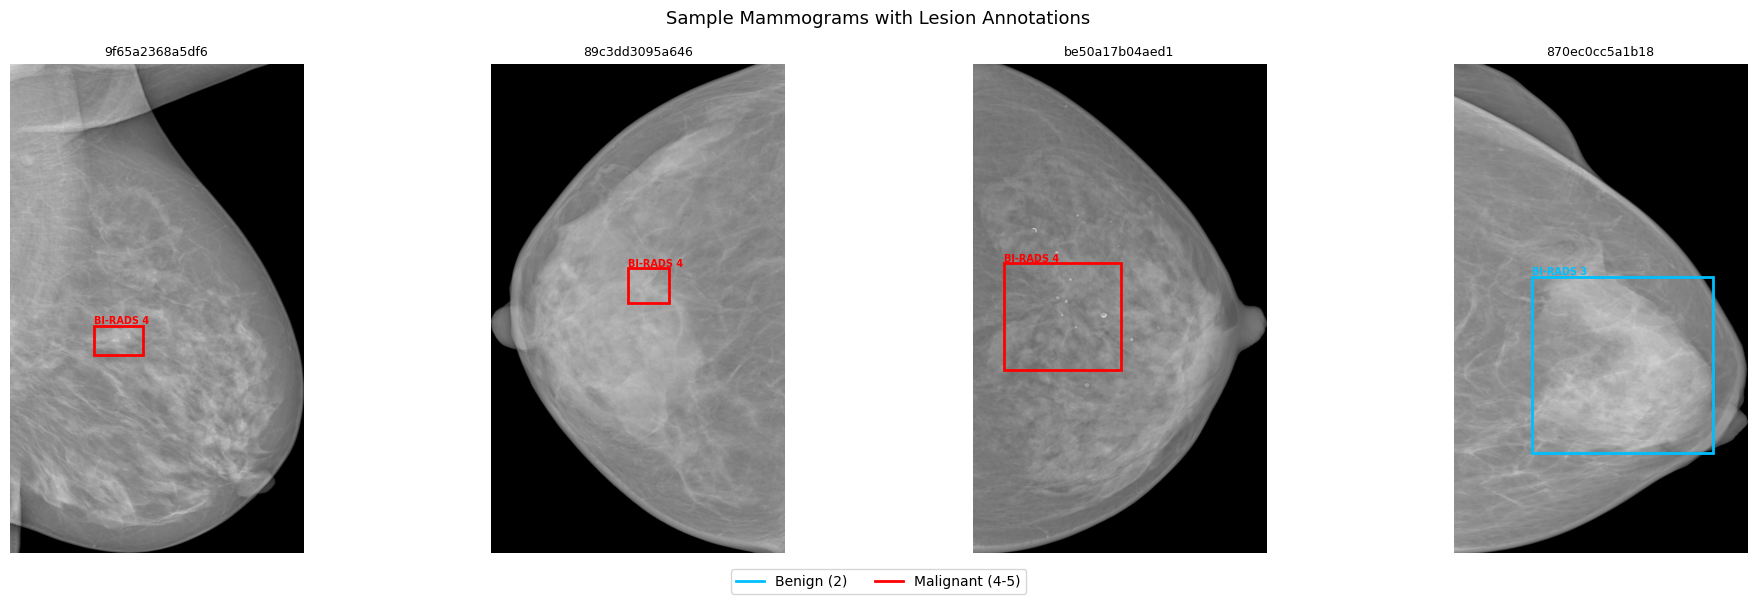

In [5]:
#@title 1.3 — Visualise Sample Mammograms with Lesion Boxes
#@markdown Images are already PNGs — load with cv2 and overlay resized_* bounding boxes.

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Build a one-time lookup: image_id_stem -> full PNG path.
# Layout: images_png/<study_folder>/<image_file>.png
# The CSV image_id is the *image file* name (e.g. 2ddfad7286c2b016931ceccd1e2c7bbc),
# not the study folder, so we must scan all study folders once and index by filename stem.
print("Building image index (scanning images_png/)...")
_images_dir = DATASET_ROOT / "images_png"
PNG_INDEX: dict = {}

for study_dir in _images_dir.iterdir():
    if study_dir.is_dir():
        for png in study_dir.glob("*.png"):
            PNG_INDEX[png.stem] = png  # stem = 32-char hex image ID

print(f"Index built: {len(PNG_INDEX):,} images found.")


def find_png(image_id: str) -> Path | None:
    """Return the Path to a PNG given its image_id (with or without .png extension)."""
    stem = Path(image_id).stem   # strip .png if present
    return PNG_INDEX.get(stem)


def plot_samples(df, n=4, seed=42):
    boxed = df[df["resized_xmin"].notna()].copy()
    sample_ids = boxed["image_id"].drop_duplicates().sample(n, random_state=seed).tolist()

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, img_id in zip(axes, sample_ids):
        png_path = find_png(img_id)

        if png_path is None:
            ax.set_title(f"{img_id[:10]}\n(not found)")
            ax.axis("off")
            continue

        img = cv2.cvtColor(cv2.imread(str(png_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img, cmap="gray")

        for _, r in boxed[boxed["image_id"] == img_id].iterrows():
            x1, y1 = r["resized_xmin"], r["resized_ymin"]
            x2, y2 = r["resized_xmax"], r["resized_ymax"]
            color = "red" if r["birads_int"] >= 4 else "deepskyblue"

            ax.add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2,
                    edgecolor=color,
                    facecolor="none"
                )
            )

            ax.text(
                x1, y1 - 4,
                f"BI-RADS {int(r['birads_int'])}",
                color=color,
                fontsize=7,
                fontweight="bold"
            )

        ax.set_title(img_id[:14], fontsize=9)
        ax.axis("off")

    from matplotlib.lines import Line2D

    fig.legend(
        handles=[
            Line2D([0], [0], color="deepskyblue", lw=2, label="Benign (2)"),
            Line2D([0], [0], color="red", lw=2, label="Malignant (4-5)"),
        ],
        loc="lower center",
        ncol=2,
        fontsize=10
    )

    plt.suptitle("Sample Mammograms with Lesion Annotations", fontsize=13)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


plot_samples(df)

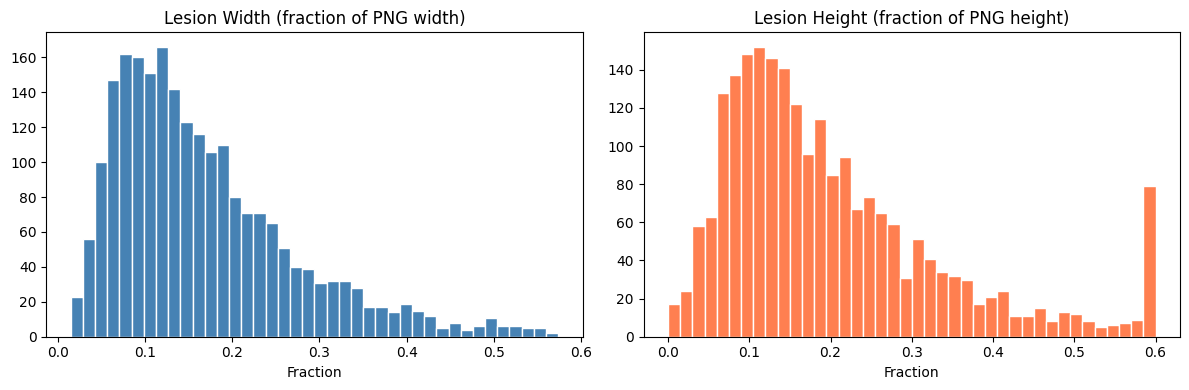

Median lesion width  : 0.143 × image width
Median lesion height : 0.164 × image height

Key insight: most lesions are SMALL relative to the full image.
→ We resize to 640×640 so YOLO has enough resolution to detect them.


In [7]:
#@title 1.4 — Bounding Box Size Distribution
#@markdown Uses resized_* coordinates matched to the PNG dimensions (1520 × 912).

PNG_W, PNG_H = 1520, 912

boxed = df[df["resized_xmin"].notna()].copy()
boxed["box_w_frac"] = (boxed["resized_xmax"] - boxed["resized_xmin"]) / PNG_W
boxed["box_h_frac"] = (boxed["resized_ymax"] - boxed["resized_ymin"]) / PNG_H

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boxed["box_w_frac"].clip(0, 0.6), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Lesion Width (fraction of PNG width)")
axes[0].set_xlabel("Fraction")
axes[1].hist(boxed["box_h_frac"].clip(0, 0.6), bins=40, color="coral", edgecolor="white")
axes[1].set_title("Lesion Height (fraction of PNG height)")
axes[1].set_xlabel("Fraction")
plt.tight_layout(); plt.show()

print(f"Median lesion width  : {boxed['box_w_frac'].median():.3f} × image width")
print(f"Median lesion height : {boxed['box_h_frac'].median():.3f} × image height")
print()
print("Key insight: most lesions are SMALL relative to the full image.")
print("→ We resize to 640×640 so YOLO has enough resolution to detect them.")

# Section 2 — Dataset Preparation
===========================================================

YOLOv8 expects its data in a specific directory structure with labels in YOLO format.

**YOLO label format** — one `.txt` file per image, each line:
```
<class_id> <x_center> <y_center> <width> <height>
```
where all coordinates are **normalised to [0, 1]** relative to image width/height.

**Directory layout we will create:**
```
lesion_det/
  dataset/
    images/
      train/   ← PNGs copied & resized from the dataset
      val/
    labels/
      train/   ← YOLO .txt labels (from resized_* box coords)
      val/
  dataset.yaml  ← tells YOLO where the data is
```

**Class mapping** (simplified binary):

| Class ID | Label | BI-RADS |
|----------|-------|---------|
| 0 | `benign` | 2 |
| 1 | `malignant` | 4, 5 |

> BI-RADS 1 (no finding) has no bounding box and is excluded. BI-RADS 3 ("probably benign") is also excluded — radiologists themselves are uncertain about these, which adds noise to training.

**Note on dataset size:** The CSV covers ~20 000 images across all folds. For fast prototyping on Kaggle we use a **stratified subset of 2 000 images** (1 600 train / 400 val). When you are ready for a full run, set `MAX_IMAGES = None` — or better, submit the full job to the AfriLink HPC cluster in Section 6.

In [8]:
#@title 2.1 — Configuration

from sklearn.model_selection import train_test_split

# ── Adjustable parameters ────────────────────────────────────────────────────
MAX_IMAGES  = 2000   # @param {type:"integer"}  Set to None to use all images
IMG_SIZE    = 640    # @param {type:"integer"}  YOLO input resolution
VAL_FRAC    = 0.20   # @param {type:"number"}   Fraction for validation
SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

DATASET_DIR = WORK_DIR / "dataset"
for split in ["train", "val"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# BI-RADS → class ID  (missing key = skip row)
CLASS_MAP   = {2: 0, 4: 1, 5: 1}
CLASS_NAMES = ["benign", "malignant"]

print(f"Subset size : {MAX_IMAGES or 'all'}")
print(f"Image size  : {IMG_SIZE}×{IMG_SIZE}")
print(f"Classes     : {CLASS_NAMES}")

Subset size : 2000
Image size  : 640×640
Classes     : ['benign', 'malignant']


# 2.2 — Filter, Subsample & Split

# Keep rows with a mappable BI-RADS (2, 4, 5) AND a valid resized bounding box

In [9]:
#@title 2.2 — Filter, Subsample & Split

# Keep rows with a mappable BI-RADS (2, 4, 5) AND a valid resized bounding box
valid = df[
    df["birads_int"].isin(CLASS_MAP.keys()) &
    df["resized_xmin"].notna()
].copy()

unique_images = valid["image_id"].drop_duplicates().tolist()
print(f"Images with usable annotations: {len(unique_images):,}")

random.seed(SEED)
if MAX_IMAGES and len(unique_images) > MAX_IMAGES:
    unique_images = random.sample(unique_images, MAX_IMAGES)
    print(f"Subsampled to : {len(unique_images):,}")

# Stratified train/val split
img_class = (
    valid[valid["image_id"].isin(unique_images)]
    .drop_duplicates("image_id")
    .set_index("image_id")["birads_int"]
    .apply(lambda v: CLASS_MAP.get(v, 0))
)
train_ids, val_ids = train_test_split(
    unique_images, test_size=VAL_FRAC,
    stratify=[img_class[i] for i in unique_images],
    random_state=SEED
)
split_map = {sid: "train" for sid in train_ids}
split_map.update({sid: "val" for sid in val_ids})
print(f"Train: {len(train_ids)} | Val: {len(val_ids)}")

# Annotation lookup: image_id → DataFrame of rows for that image
ann_lookup = {
    img_id: grp
    for img_id, grp in valid[valid["image_id"].isin(unique_images)].groupby("image_id")
}

Images with usable annotations: 964
Train: 771 | Val: 193


In [10]:
#@title 2.3 — Copy PNGs & Write YOLO Labels
#@markdown No DICOM conversion needed. We copy each PNG to the YOLO directory,
#@markdown resize it to IMG_SIZE, then write the YOLO label file using resized_* coords.

ok = fail = 0

for img_id in unique_images:
    split   = split_map[img_id]
    png_src = find_png(img_id)   # defined in Section 1, cell 1.3

    if png_src is None:
        fail += 1; continue

    img = cv2.imread(str(png_src))
    if img is None:
        fail += 1; continue

    orig_h, orig_w = img.shape[:2]   # 912 × 1520 for this dataset
    img_resized    = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    out_png        = DATASET_DIR / "images" / split / img_id
    cv2.imwrite(str(out_png), img_resized)

    # Build YOLO label lines from resized_* coordinates
    lines = []
    for _, r in ann_lookup[img_id].iterrows():
        cls_id = CLASS_MAP.get(r["birads_int"])
        if cls_id is None: continue
        x1, y1 = r["resized_xmin"], r["resized_ymin"]
        x2, y2 = r["resized_xmax"], r["resized_ymax"]
        # Normalise to [0, 1] using the original PNG dimensions
        xc = ((x1 + x2) / 2) / orig_w
        yc = ((y1 + y2) / 2) / orig_h
        bw = (x2 - x1) / orig_w
        bh = (y2 - y1) / orig_h
        xc, yc, bw, bh = [max(0.0, min(1.0, v)) for v in [xc, yc, bw, bh]]
        if bw > 0 and bh > 0:
            lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    # Write label file (empty = background image; still valid for YOLO)
    stem    = Path(img_id).stem
    out_lbl = DATASET_DIR / "labels" / split / f"{stem}.txt"
    out_lbl.write_text("\n".join(lines))
    ok += 1

    if (ok + fail) % 200 == 0:
        print(f"  {ok+fail}/{len(unique_images)} | ok={ok} fail={fail}")

print(f"Done. Prepared: {ok} | Skipped: {fail}")

  200/964 | ok=200 fail=0
  400/964 | ok=400 fail=0
  600/964 | ok=600 fail=0
  800/964 | ok=800 fail=0
Done. Prepared: 964 | Skipped: 0


In [15]:
#@title 2.4 — Write dataset.yaml

import yaml

dataset_yaml = {
    "path"  : str(DATASET_DIR),
    "train" : "images/train",
    "val"   : "images/val",
    "nc"    : len(CLASS_NAMES),
    "names" : CLASS_NAMES,
}

yaml_path = WORK_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print(yaml.dump(dataset_yaml))

n_tr_img = len(list((DATASET_DIR / "images" / "train").glob("*.png")))
n_vl_img = len(list((DATASET_DIR / "images" / "val").glob("*.png")))
n_tr_lbl = len(list((DATASET_DIR / "labels" / "train").glob("*.txt")))
print(f"Train images: {n_tr_img} | labels: {n_tr_lbl}")
print(f"Val   images: {n_vl_img}")

names:
- benign
- malignant
nc: 2
path: /kaggle/working/lesion_det/dataset
train: images/train
val: images/val

Train images: 771 | labels: 771
Val   images: 193


# Section 3 — Baseline Model: YOLOv8n
===========================================================

**YOLOv8** (You Only Look Once, version 8) is a single-stage object detector that processes the entire image in one forward pass, making it fast enough to run in real time. It predicts bounding boxes and class probabilities simultaneously via a grid of anchors.

We start with **YOLOv8n** (nano) — the smallest and fastest variant. The goal here is not top accuracy but a fast sanity check:

- Does the data pipeline work?
- Can the model overfit on a tiny subset? (If not, something is wrong.)
- What does a baseline mAP look like?

**Model variants (smallest → largest):**

| Model | Params | Speed | mAP on COCO |
|-------|--------|-------|-------------|
| YOLOv8n | 3.2M | fastest | 37.3 |
| YOLOv8s | 11.2M | fast | 44.9 |
| YOLOv8m | 25.9M | moderate | 50.2 |
| YOLOv8l | 43.7M | slow | 52.9 |

> On Kaggle GPUs, YOLOv8n with 10 epochs on 2 000 images takes ~10 minutes. Use this for quick experiments, then move to YOLOv8s for a better model (Section 4).

In [16]:
#@title 3.1 — Train YOLOv8n Baseline (10 epochs)
#@markdown Quick run to confirm the pipeline works end-to-end.

from ultralytics import YOLO

baseline_model = YOLO("yolov8n.pt")   # auto-downloads pretrained weights from Ultralytics

baseline_results = baseline_model.train(
    data    = str(yaml_path),
    epochs  = 10, # change this to your preferred number of epochs during actual experimentation
    imgsz   = IMG_SIZE,
    batch   = 16,
    device  = device,
    project = str(WORK_DIR / "runs"),
    name    = "baseline_yolov8n",
    exist_ok= True,
    verbose = False,
)

print("Baseline training complete.")
print(f"Best weights: {baseline_model.trainer.best}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lesion_det/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6

In [17]:
#@title 3.2 — Evaluate Baseline on Validation Set

baseline_metrics = baseline_model.val(data=str(yaml_path), verbose=False)

map50   = baseline_metrics.box.map50
map5095 = baseline_metrics.box.map
prec    = baseline_metrics.box.mp
rec     = baseline_metrics.box.mr

print("=== Baseline YOLOv8n Metrics ===")
print(f"  mAP@0.50       : {map50:.4f}")
print(f"  mAP@0.50:0.95  : {map5095:.4f}")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print()
print("mAP@0.50 is the primary metric for this challenge.")
print("Can you beat this baseline with YOLOv8s and better augmentation?")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3966.7±721.7 MB/s, size: 288.0 KB)
val: Scanning /kaggle/working/lesion_det/dataset/labels/val.cache... 193 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 193/193 67.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.6it/s 2.8s0.1s
                   all        193        270      0.728      0.168      0.168     0.0793
Speed: 2.2ms preprocess, 4.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
=== Baseline YOLOv8n Metrics ===
  mAP@0.50       : 0.1676
  mAP@0.50:0.95  : 0.0793
  Precision      : 0.7280
  Recall         : 0.1679

mAP@0.50 is the primary metric for this challenge.
Can you beat this baseline with YOLOv8s and better augmentation?

# Section 4 — Improved Model: YOLOv8s + Augmentation
===========================================================

Now we try to actually improve performance. Three levers:

### 1. Bigger model backbone
Switch from YOLOv8n (3.2M params) to YOLOv8s (11.2M params). More capacity to learn subtle lesion textures.

### 2. Medical-aware augmentation
Standard image augmentation (flip, rotate, colour jitter) helps. For mammography specifically:
- **Horizontal flip** — the mirrored breast is an equally valid training example
- **Moderate rotation** (±10°) — patient positioning varies
- **CLAHE** (Contrast Limited Adaptive Histogram Equalisation) — boosts subtle tissue contrast
- Avoid excessive distortion that would alter lesion morphology

### 3. More epochs
30 epochs is enough to see meaningful convergence on 2 000 images. On the full dataset you'd want 100+.

> **Experiment ideas:**
> - Compare YOLOv8n vs YOLOv8s mAP
> - Turn off augmentation to see how much it helps
> - Try different `imgsz` values (640 vs 960)
> - Increase `MAX_IMAGES` and rerun Section 2 to see scaling behaviour
>
> When you have a configuration worth a full-scale run, move to Section 6 to submit it to the AfriLink HPC cluster.

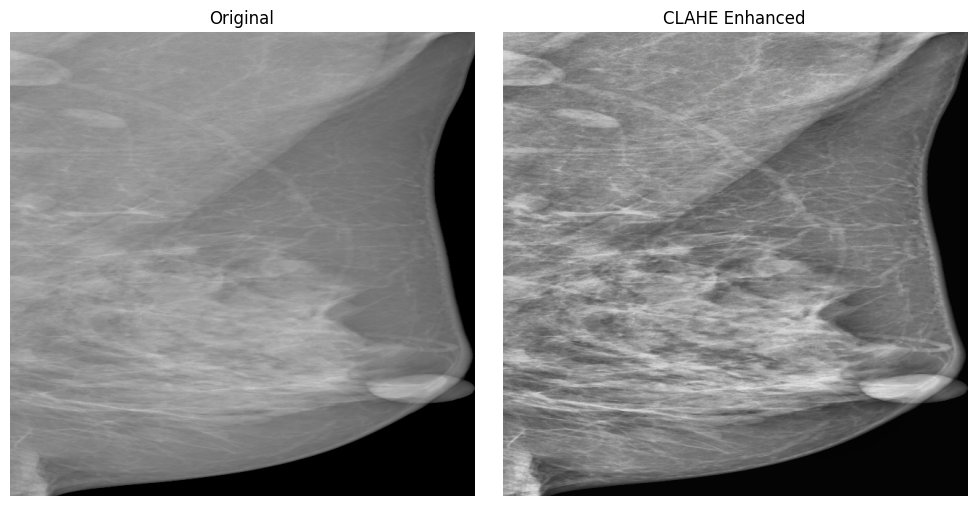

In [18]:
#@title 4.1 — CLAHE Preprocessing (optional, applied at read time)
#@markdown CLAHE boosts local contrast in low-contrast regions, which helps lesion visibility.
#@markdown We apply it during visualisation here; YOLOv8's augmentation handles it at train time.

def apply_clahe(img_rgb: np.ndarray, clip_limit: float = 2.0, tile: int = 8) -> np.ndarray:
    """Apply CLAHE to the luminance channel of an RGB image."""
    lab  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    cl    = clahe.apply(l)
    lab   = cv2.merge([cl, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


# Quick visual comparison
sample_png = list((DATASET_DIR / "images" / "train").glob("*.png"))
if sample_png:
    img_orig = cv2.cvtColor(cv2.imread(str(sample_png[0])), cv2.COLOR_BGR2RGB)
    img_clahe = apply_clahe(img_orig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_orig,  cmap="gray"); axes[0].set_title("Original")
    axes[1].imshow(img_clahe, cmap="gray"); axes[1].set_title("CLAHE Enhanced")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No PNG images found in train directory — run Section 2 first.")

In [19]:
#@title 4.2 — Train YOLOv8s with Augmentation (30 epochs)
#@markdown YOLOv8's built-in augmentation is controlled by hyperparameter args.
#@markdown We enable fliplr, moderate rotation, and mosaic.

improved_model = YOLO("yolov8s.pt")

improved_results = improved_model.train(
    data      = str(yaml_path),
    epochs    = 30,
    imgsz     = IMG_SIZE,
    batch     = 8,         # smaller batch because model is larger
    device    = device,
    project   = str(WORK_DIR / "runs"),
    name      = "improved_yolov8s",
    exist_ok  = True,
    verbose   = False,
    # Augmentation hyperparameters
    fliplr    = 0.5,       # horizontal flip probability
    degrees   = 10.0,      # rotation degrees
    mosaic    = 0.5,       # mosaic augmentation probability
    hsv_s     = 0.2,       # saturation variation (subtle — grayscale images)
    hsv_v     = 0.3,       # brightness variation
    scale     = 0.3,       # image scale ±30%
)

print("Improved training complete.")
print(f"Best weights: {improved_model.trainer.best}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lesion_det/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.2, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=improved_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [20]:
#@title 4.3 — Compare Baseline vs Improved

improved_metrics = improved_model.val(data=str(yaml_path), verbose=False)

rows = [
    ["YOLOv8n (baseline)",  f"{map50:.4f}",                       f"{map5095:.4f}",              f"{prec:.4f}",   f"{rec:.4f}"],
    ["YOLOv8s (improved)",
     f"{improved_metrics.box.map50:.4f}",
     f"{improved_metrics.box.map:.4f}",
     f"{improved_metrics.box.mp:.4f}",
     f"{improved_metrics.box.mr:.4f}"],
]

cmp_df = pd.DataFrame(rows, columns=["Model", "mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"])
print(cmp_df.to_string(index=False))
print()
delta = improved_metrics.box.map50 - map50
print(f"Improvement in mAP@0.5: {delta:+.4f}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2827.7±1173.6 MB/s, size: 301.9 KB)
val: Scanning /kaggle/working/lesion_det/dataset/labels/val.cache... 193 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 193/193 22.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.4it/s 3.8s0.2s
                   all        193        270      0.805      0.174      0.215      0.091
Speed: 2.3ms preprocess, 9.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
             Model mAP@0.5 mAP@0.5:0.95 Precision Recall
YOLOv8n (baseline)  0.1676       0.0793    0.7280 0.1679
YOLOv8s (improved)  0.2149       0.0910    0.8049 0.1735

Improvement in mAP@0.5: +0.0473


# Section 5 — Evaluation & Visualisation
===========================================================

Numbers alone do not tell the full story. For medical imaging it is especially important to look at:

- **True positives** — correct lesion detections
- **False negatives** — missed lesions (dangerous — the model did not flag what was there)
- **False positives** — spurious detections (annoying but less dangerous)

The **precision–recall curve** shows the trade-off between these at different confidence thresholds. For a medical screening tool, you typically want **high recall** (catch everything) even at the cost of lower precision (some false alarms) — it is better to flag a normal image for review than to miss a malignancy.

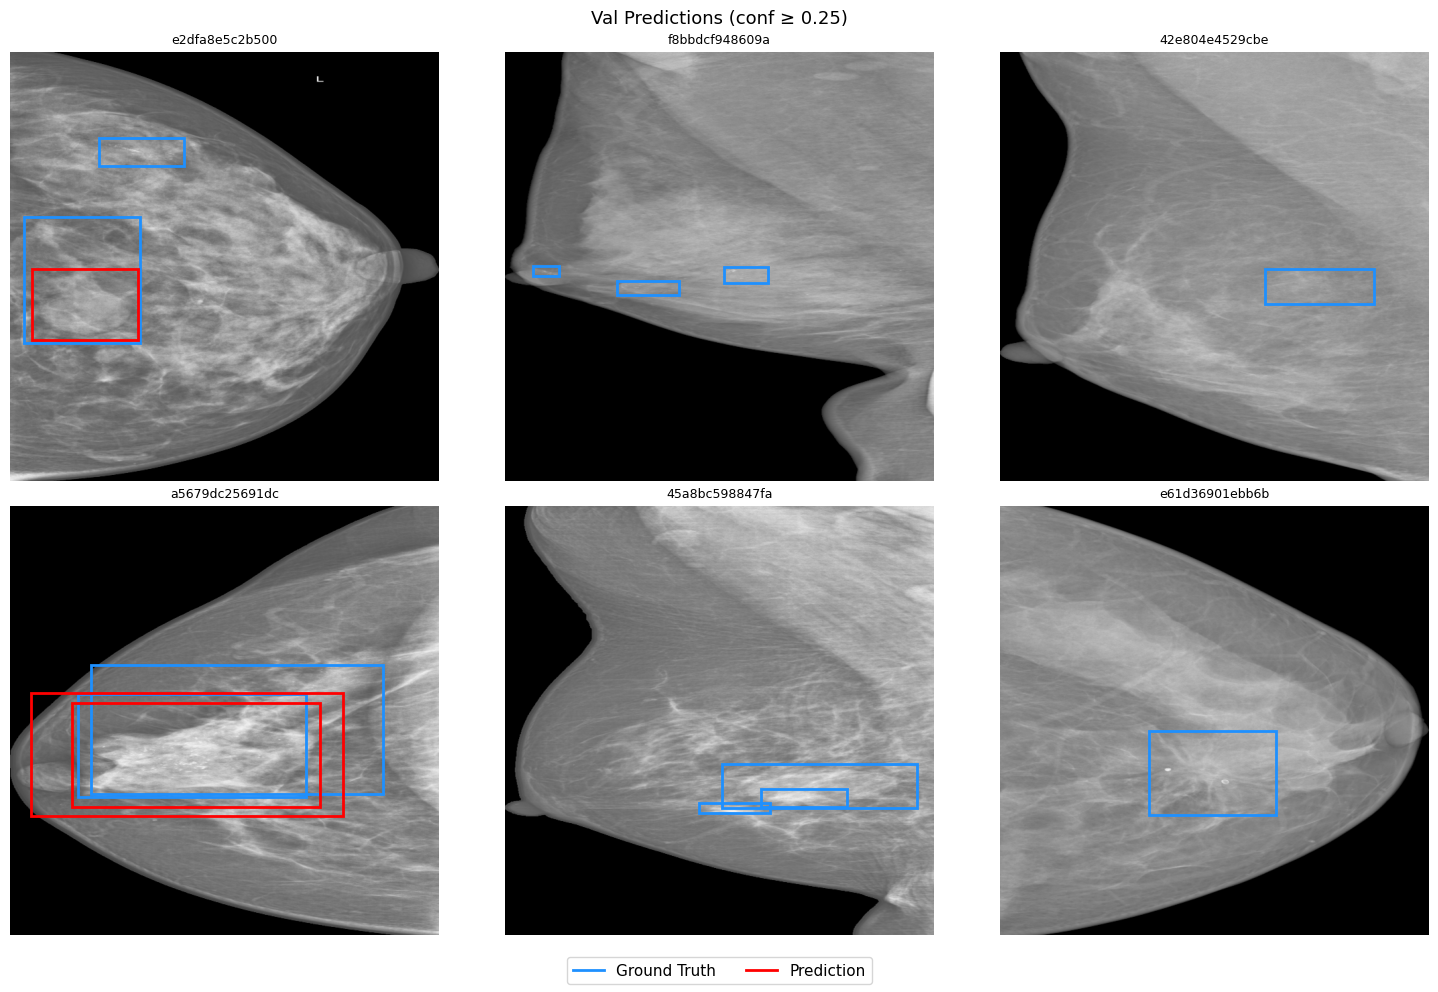

In [23]:
#@title 5.1 — Visualise Predictions on Validation Images

CONF_THRESHOLD = 0.25   # @param {type:"number"}   Detection confidence threshold
N_SHOW         = 6      # @param {type:"integer"}  Number of images to display

val_images = list((DATASET_DIR / "images" / "val").glob("*.png"))
random.seed(SEED)
samples    = random.sample(val_images, min(N_SHOW, len(val_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    img    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w   = img.shape[:2]

    # Run inference
    results = improved_model.predict(
        source=str(img_path), conf=CONF_THRESHOLD, verbose=False
    )
    preds   = results[0].boxes

    ax.imshow(img, cmap="gray")

    # Plot ground-truth boxes (blue)
    lbl_path = DATASET_DIR / "labels" / "val" / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            if not line: continue
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = (xc - bw / 2) * w; y1 = (yc - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor="dodgerblue", facecolor="none"
            )
            ax.add_patch(rect)

    # Plot predicted boxes (red)
    if preds is not None and len(preds):
        for box in preds.xyxyn.cpu().numpy():
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1 * w, y1 * h), (x2 - x1) * w, (y2 - y1) * h,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

    ax.set_title(img_path.stem[:14], fontsize=9)
    ax.axis("off")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color="dodgerblue", lw=2, label="Ground Truth"),
    Line2D([0],[0], color="red",        lw=2, label="Prediction"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11)
plt.suptitle(f"Val Predictions (conf ≥ {CONF_THRESHOLD})", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [24]:
#@title 5.2 — Per-Class Metrics

maps_per_class = improved_metrics.box.maps   # per-class mAP@0.5:0.95

print("Per-class mAP@0.50:0.95")
for cid, cls_name in enumerate(CLASS_NAMES):
    val = maps_per_class[cid] if cid < len(maps_per_class) else float("nan")
    print(f"  {cls_name:12}: {val:.4f}")

print()
print("Observation: Malignant lesions are typically harder to detect than benign.")
print("  If malignant mAP is much lower, consider class-weighting or focal loss.")

Per-class mAP@0.50:0.95
  benign      : 0.0000
  malignant   : 0.1819

Observation: Malignant lesions are typically harder to detect than benign.
  If malignant mAP is much lower, consider class-weighting or focal loss.


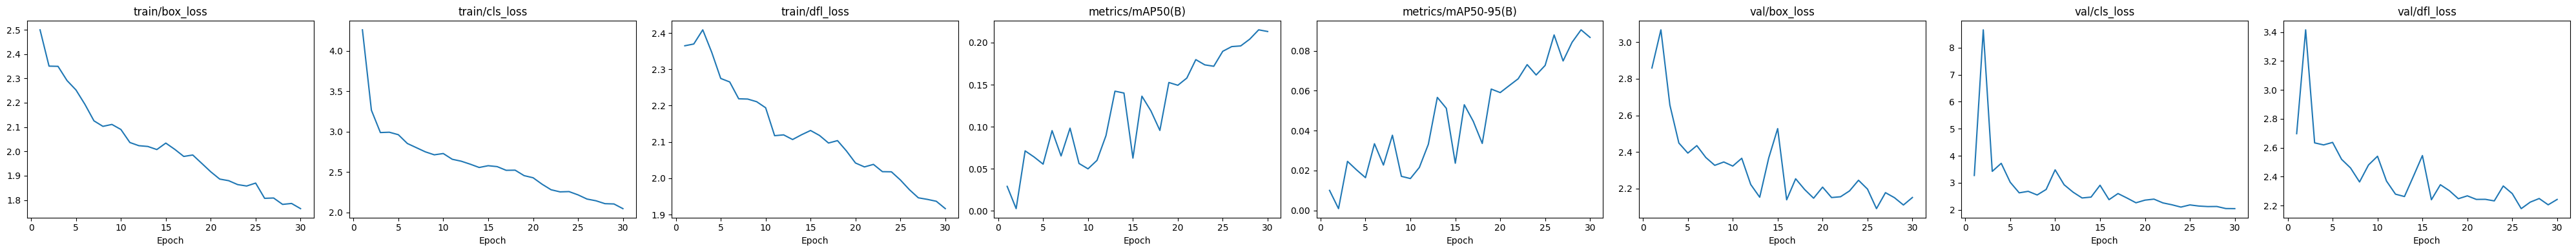

In [25]:
#@title 5.3 — Training Loss Curve
#@markdown YOLOv8 saves training metrics to a CSV. Plot them here.

results_csv = WORK_DIR / "runs" / "improved_yolov8s" / "results.csv"

if results_csv.exists():
    train_log = pd.read_csv(results_csv)
    train_log.columns = train_log.columns.str.strip()

    metric_cols = [c for c in train_log.columns if "mAP" in c or "loss" in c.lower()]
    n = len(metric_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, metric_cols):
        ax.plot(train_log["epoch"], train_log[col])
        ax.set_title(col)
        ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found — check the run directory path.")

# Section 6 — Scale-Up: Full Training on AfriLink HPC
===========================================================

## When to use this section

You have:
- Validated your data pipeline (Sections 2–3 ran without errors)
- Picked a model size and augmentation configuration (Section 4)
- Confirmed the Kaggle-GPU baseline mAP and want to improve it significantly

Training on the full VinDr-Mammo dataset (~20 000 images, 100+ epochs) takes 6–12 hours on a Kaggle T4. The AfriLink HPC cluster's **NVIDIA A100 80GB** nodes can cut that to 1–2 hours.

---

## How it works

```
Your Kaggle Notebook              AfriLink HPC Cluster
+─────────────────────+            +──────────────────────+
│ AfriLink SDK        │  SSH/SCP   │ Login Node           │
│ client.finetune()   │ ────────>  │  └─ SLURM sbatch     │
│ + dataset upload    │            │     └─ A100 GPU node  │
+─────────────────────+            │        training runs  │
                                   │        weights saved  │
                                   +──────────────────────+
```

The SDK handles authentication, file transfer, job submission, and progress polling — you only need to call three methods.

---

## Step-by-step

### Step 6.1 — Install & Authenticate

You need a **DataSpires account** for this section. Sign up at [dataspires.com](https://dataspires.com) if you have not already.

In [26]:
#@title 6.1 — Install AfriLink SDK & Authenticate
#@markdown Run this cell and enter your DataSpires email + password when prompted.
#@markdown Cluster authentication is fully automatic after that.

!pip install -q afrilink-sdk

from afrilink import AfriLinkClient

hpc = AfriLinkClient()
hpc.authenticate()   # prompts for DataSpires credentials; HPC auth is automatic

print(f"Session active. Certificate valid for {hpc.cert_minutes_remaining:.0f} more minutes.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.1/102.1 kB 3.5 MB/s eta 0:00:00
CINECA credentials provisioned successfully

DataSpires Authentication Required
Your DataSpires account is used for usage tracking and billing.
Don't have an account? Sign up at https://dataspires.com



DataSpires Email:  ianomunga@gmail.com
DataSpires Password:  ········



Authenticating with DataSpires...
  Authenticated as: ianomunga@gmail.com
  User ID: ccab4bb3-2705-4979-be14-2ca8bf871fbb
  Balance: $8.52
Authenticating [██████████████████████████████] 100%                                      

  Session authenticated for ~11h 59m
  We will warn you before it expires.
Session active. Certificate valid for 720 more minutes.


In [27]:
#@title 6.2 — Verify Cluster Connectivity

code, out, err = hpc.run_command("hostname && squeue -u $USER --noheader | wc -l")
print("HPC hostname :", out.splitlines()[0] if out else "(no output)")
print("Jobs in queue:", out.splitlines()[1].strip() if len(out.splitlines()) > 1 else "0")

HPC hostname : login07.leonardo.local
Jobs in queue: 0


### Step 6.3 — Upload Dataset & Submit Training Job

The SDK's `finetune()` method is designed for LLM fine-tuning, but we can use `run_command()` and `upload_dataset()` to run any SLURM job — including a YOLOv8 training run.

The cell below:
1. Packages the prepared dataset directory into a tar archive
2. Uploads it to your `$WORK` directory on the cluster
3. Writes a SLURM batch script that runs YOLOv8 training inside a Singularity container
4. Submits the job and returns a job ID

> **Resource estimate:** YOLOv8s, 100 epochs, 20 000 images on 1× A100 80GB ≈ 90–120 minutes.
> Billed at the standard AfriLink rate ($2.00/GPU-hour). Check your DataSpires dashboard for real-time usage.

In [28]:
#@title 6.3 — Package & Upload Dataset

import tarfile

ARCHIVE_PATH = WORK_DIR / "lesion_dataset.tar.gz"

print("Archiving dataset...")
with tarfile.open(ARCHIVE_PATH, "w:gz") as tar:
    tar.add(str(DATASET_DIR), arcname="lesion_dataset")
    tar.add(str(yaml_path),   arcname="dataset.yaml")

size_mb = ARCHIVE_PATH.stat().st_size / 1e6
print(f"Archive: {ARCHIVE_PATH.name} ({size_mb:.1f} MB)")

print("Uploading to HPC cluster...")
hpc.upload_dataset(str(ARCHIVE_PATH), dataset_name="lesion_det_dataset")
print("Upload complete.")

Archiving dataset...
Archive: lesion_dataset.tar.gz (231.2 MB)
Uploading to HPC cluster...
Upload complete.


In [36]:
# Fix dataset.yaml paths for the container
fixed_yaml = """names:
- benign
- malignant
nc: 2
path: /workspace/work/lesion_dataset
train: images/train
val: images/val
"""

yaml_path = WORK_DIR / "dataset.yaml"
yaml_path.write_text(fixed_yaml)
hpc.transfer.upload_file(str(yaml_path), f"{WORK_PATH}/dataset.yaml")
print("Fixed dataset.yaml uploaded")

# Verify
_, out, _ = hpc.run_command(f"cat {WORK_PATH}/dataset.yaml")
print(out)

Fixed dataset.yaml uploaded
names:
- benign
- malignant
nc: 2
path: /workspace/work/lesion_dataset
train: images/train
val: images/val



In [37]:
#@title 6.4 — Write & Submit SLURM Training Script
#@markdown Adjust EPOCHS and MODEL_VARIANT below, then run this cell.

EPOCHS        = 100          # @param {type:"integer"}
MODEL_VARIANT = "yolov8s.pt" # @param ["yolov8s.pt", "yolov8m.pt", "yolov8l.pt"]
N_GPUS        = 1            # @param {type:"integer"}
TIME_LIMIT    = "04:00:00"   # @param {type:"string"}

PARTITION = "boost_usr_prod"
QOS       = "normal"
ACCOUNT   = "aih4a_dataspire"

# ── Resolve $WORK to its real absolute path ──────────────────────────────
_, _w, _ = hpc.run_command("echo $WORK")
WORK_PATH = _w.strip()
print(f"Resolved WORK_PATH = {WORK_PATH}")

# ── Pre-flight checks ─────────────────────────────────────────────────────
ARCHIVE_REMOTE = f"{WORK_PATH}/datasets/lesion_det_dataset/lesion_dataset.tar.gz"
SIF_REMOTE     = f"{WORK_PATH}/containers/afrilink-yolo.sif"
_, _a, _ = hpc.run_command(f"ls {ARCHIVE_REMOTE} 2>/dev/null || echo MISSING")
_, _s, _ = hpc.run_command(f"ls {SIF_REMOTE}     2>/dev/null || echo MISSING")
print("Archive :", "OK" if "MISSING" not in _a else "MISSING — re-run cell 6.3")
print("SIF     :", "OK" if "MISSING" not in _s else "MISSING — build & upload afrilink-yolo.sif first")

# ── Write train_yolo.py locally ───────────────────────────────────────────
train_py = (
    "from ultralytics import YOLO\n"
    f"model = YOLO('/workspace/work/{MODEL_VARIANT}')\n"
    "results = model.train(\n"
    "    data='/workspace/work/dataset.yaml',\n"
    f"    epochs={EPOCHS},\n"
    "    imgsz=640,\n"
    "    batch=32,\n"
    "    device=0,\n"
    "    project='/workspace/work/runs',\n"
    "    name='hpc_full_run',\n"
    "    exist_ok=True,\n"
    "    fliplr=0.5,\n"
    "    degrees=10.0,\n"
    "    mosaic=0.5,\n"
    "    scale=0.3,\n"
    ")\n"
    "print('Training complete. Best weights:', results.save_dir)\n"
)

train_py_path = WORK_DIR / "train_yolo.py"
train_py_path.write_text(train_py)
print(f"Local file written: {train_py_path} ({train_py_path.stat().st_size} bytes)")

# ── Upload train_yolo.py and verify ──────────────────────────────────────
TRAIN_PY_REMOTE = f"{WORK_PATH}/train_yolo.py"
result = hpc.transfer.upload_file(str(train_py_path), TRAIN_PY_REMOTE)
print(f"upload_file result: success={result.success}, error={result.error}")

_, verify_out, _ = hpc.run_command(f"ls -la {TRAIN_PY_REMOTE} 2>/dev/null || echo NOT_FOUND")
print(f"Remote verify: {verify_out.strip()}")

if "NOT_FOUND" in verify_out or not result.success:
    raise RuntimeError(f"train_yolo.py upload failed! error={result.error}")

# ── Build and upload the SLURM batch script ───────────────────────────────
slurm_script = "\n".join([
    "#!/bin/bash",
    "#SBATCH --job-name=lesion_det",
    f"#SBATCH --partition={PARTITION}",
    f"#SBATCH --qos={QOS}",
    f"#SBATCH --account={ACCOUNT}",
    "#SBATCH --nodes=1",
    "#SBATCH --ntasks-per-node=1",
    "#SBATCH --cpus-per-task=8",
    f"#SBATCH --gpus-per-node={N_GPUS}",
    "#SBATCH --mem=64G",
    f"#SBATCH --time={TIME_LIMIT}",
    f"#SBATCH --output={WORK_PATH}/lesion_det_%j.log",
    f"#SBATCH --error={WORK_PATH}/lesion_det_%j.err",
    "",
    "set -e",
    "",
    "# Extract dataset (idempotent)",
    'if [ ! -d "$WORK/lesion_dataset" ]; then',
    "    tar -xzf $WORK/datasets/lesion_det_dataset/lesion_dataset.tar.gz -C $WORK",
    "fi",
    "cp -n $WORK/datasets/lesion_det_dataset/dataset.yaml $WORK/dataset.yaml 2>/dev/null || true",
    "",
    "# Run training inside the Singularity container",
    "singularity exec --nv --env YOLO_CONFIG_DIR=/tmp/ultralytics_cfg --bind $WORK:/workspace/work $WORK/containers/afrilink-yolo.sif bash -c 'mkdir -p /tmp/ultralytics_cfg && python3 /workspace/work/train_yolo.py'",
]) + "\n"

slurm_path = WORK_DIR / "train_lesion.sh"
slurm_path.write_text(slurm_script)
SLURM_REMOTE = f"{WORK_PATH}/train_lesion.sh"
result2 = hpc.transfer.upload_file(str(slurm_path), SLURM_REMOTE)
print(f"SLURM script upload: success={result2.success}, error={result2.error}")

# ── Submit ────────────────────────────────────────────────────────────────
code, out, err = hpc.run_command(f"sbatch {SLURM_REMOTE}")
print("SLURM response:", out.strip())
if err.strip():
    print("Stderr:", err.strip())

slurm_job_id = None
for token in out.split():
    if token.isdigit():
        slurm_job_id = token
        break

if slurm_job_id:
    print(f"\nJob submitted. SLURM ID = {slurm_job_id}")
    print("Monitor: re-run cell 6.5 at any time.")
    print("Expected runtime: ~90-120 min on 1x A100.")
else:
    print("Could not parse a SLURM job ID — check the response above.")

Resolved WORK_PATH = /leonardo_work/AIH4A_dataspire
Archive : OK
SIF     : OK
Local file written: /kaggle/working/lesion_det/train_yolo.py (402 bytes)
upload_file result: success=True, error=None
Remote verify: -rw-r--r--. 1 iomunga0 interactive 402 Apr  9 19:49 /leonardo_work/AIH4A_dataspire/train_yolo.py
SLURM script upload: success=True, error=None
SLURM response: Submitted batch job 39516717
Stderr: Warning: Permanently added 'login.leonardo.cineca.it' (RSA) to the list of known hosts.

Job submitted. SLURM ID = 39516717
Monitor: re-run cell 6.5 at any time.
Expected runtime: ~90-120 min on 1x A100.


In [41]:
#@title 6.5 — Monitor Job Status
#@markdown Re-run this cell at any time to check progress.
#@markdown Shows queue state while running, sacct exit status + error log once finished.

if not slurm_job_id:
    print("No job ID recorded — run cell 6.4 first.")
else:
    # 1. Queue status (only present while job is PENDING or RUNNING)
    _, q_out, _ = hpc.run_command(f"squeue -j {slurm_job_id} --format='%.8i %.8T %.10M %.6D %R'")
    if q_out.strip():
        print("Queue status:")
        print(q_out.strip())
    else:
        print("Job not in queue (finished or failed).")

    # 2. Accounting record — definitive exit status (works after job leaves queue)
    _, acct, _ = hpc.run_command(
        f"sacct -j {slurm_job_id} --format=JobID,State,ExitCode,Elapsed,AllocCPUS,ReqMem --noheader"
    )
    if acct.strip():
        print("\nAccounting record:")
        print(acct.strip())

    # 3. Tail stdout log
    _, log_out, _ = hpc.run_command(f"tail -n 30 $WORK/lesion_det_{slurm_job_id}.log 2>/dev/null")
    if log_out.strip():
        print("\n--- Last 30 lines of stdout log ---")
        print(log_out.strip())

    # 4. Tail stderr log — this is where failures show up
    _, err_out, _ = hpc.run_command(f"tail -n 30 $WORK/lesion_det_{slurm_job_id}.err 2>/dev/null")
    if err_out.strip():
        print("\n--- Last 30 lines of stderr log ---")
        print(err_out.strip())
    else:
        print("\n(stderr log empty or not yet written)")


Job not in queue (finished or failed).

Accounting record:
39516717      COMPLETED      0:0   00:07:00          8        64G 
39516717.ba+  COMPLETED      0:0   00:07:00          8            
39516717.ex+  COMPLETED      0:0   00:07:00          8

--- Last 30 lines of stdout log ---
Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size

     98/100      7.91G      1.405      1.143      1.519         53        640: 0% ──────────── 0/25  0.1s
     98/100      7.91G      1.407      1.163      1.564         52        640: 4% ──────────── 1/25 2.7it/s 0.2s<9.0s
     98/100      7.91G       1.43      1.214      1.599         47        640: 8% ╸─────────── 2/25 4.2it/s 0.4s<5.4s
     98/100      7.91G       1.41      1.198      1.577         43        640: 12% ━─────────── 3/25 5.7it/s 0.5s<3.9s
     98/100      7.91G      1.446      1.244      1.598         56        640: 16% ━╸────────── 4/25 6.3it/s 0.6s<3.3s
     98/100      7.91G      1.423      1.208      1.572       

In [43]:
#@title 6.6 — Download Trained Weights
#@markdown Run this after the job shows status COMPLETED.

HPC_WEIGHTS_PATH = f"$WORK/runs/hpc_full_run/weights/best.pt"
LOCAL_WEIGHTS    = str(WORK_DIR / "best_hpc.pt")

code, out, err = hpc.run_command(f"ls -lh {HPC_WEIGHTS_PATH}")
if code == 0:
    print(f"Weights found: {out.strip()}")
    hpc.transfer.download_file(HPC_WEIGHTS_PATH, LOCAL_WEIGHTS)
    print(f"Downloaded to: {LOCAL_WEIGHTS}")

    # Write a Kaggle-local dataset.yaml for validation
    local_yaml = WORK_DIR / "dataset_local.yaml"
    local_yaml.write_text(
        "names:\n"
        "- benign\n"
        "- malignant\n"
        "nc: 2\n"
        f"path: {WORK_DIR / 'dataset'}\n"
        "train: images/train\n"
        "val: images/val\n"
    )

    # Load and evaluate the HPC-trained model
    hpc_model   = YOLO(LOCAL_WEIGHTS)
    hpc_metrics = hpc_model.val(data=str(local_yaml), verbose=False)
    print(f"HPC model mAP@0.5: {hpc_metrics.box.map50:.4f}")
else:
    print(f"Weights not found yet. Check job status in cell 6.5.")
    print(err)

Weights found: -rw-r--r--. 1 iomunga0 interactive 22M Apr  9 19:56 /leonardo_work/AIH4A_dataspire/runs/hpc_full_run/weights/best.pt
Downloaded to: /kaggle/working/lesion_det/best_hpc.pt
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3624.0±768.4 MB/s, size: 315.2 KB)
val: Scanning /kaggle/working/lesion_det/dataset/labels/val.cache... 193 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 193/193 24.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.5it/s 3.7s0.2s
                   all        193        270      0.854      0.199      0.249     0.0932
Speed: 2.2ms preprocess, 9.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val4
HPC model mAP@0.5: 0.2494


In [ ]:
#@title 6.7 — Session Recovery (if your notebook timed out)
#@markdown If your Kaggle session disconnected while the job was running,
#@markdown re-authenticate here and check job status without re-running everything.

recovery = hpc.recover_session(str(WORK_DIR / "recovered_weights"))

print(f"Re-authenticated : {recovery.re_authenticated}")
print(f"Jobs tracked     : {len(recovery.jobs)}")
for job_info in recovery.jobs:
    print(f"  Job {job_info.get('job_id','?')} → {job_info.get('status','?')}")
print(f"Files retrieved  : {recovery.files_retrieved}")